In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import warnings
warnings.filterwarnings('ignore')

# Load preprocessed data
X_train = pd.read_csv('../data/X_train.csv')
X_test = pd.read_csv('../data/X_test.csv')
y_train = pd.read_csv('../data/y_train.csv').squeeze()
y_test = pd.read_csv('../data/y_test.csv').squeeze()

print("Libraries imported!")
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape:  {y_test.shape}")

Libraries imported!
X_train shape: (1166, 86)
X_test shape:  (292, 86)
y_train shape: (1166,)
y_test shape:  (292,)


In [3]:
# Define all models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.001),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42)
}

# Train and evaluate all models
results = {}

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    preds = model.predict(X_test)
    
    # Evaluate
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)
    
    results[name] = {'RMSE': rmse, 'MAE': mae, 'R2': r2}
    print(f"{name} trained!")
    print(f"   RMSE: {rmse:.4f} | MAE: {mae:.4f} | R²: {r2:.4f}")
    print()


Linear Regression trained!
   RMSE: 0.0029 | MAE: 0.0020 | R²: 0.8906

Ridge Regression trained!
   RMSE: 0.0029 | MAE: 0.0019 | R²: 0.8934

Lasso Regression trained!
   RMSE: 0.0038 | MAE: 0.0026 | R²: 0.8210

Decision Tree trained!
   RMSE: 0.0054 | MAE: 0.0037 | R²: 0.6286

Random Forest trained!
   RMSE: 0.0032 | MAE: 0.0021 | R²: 0.8716



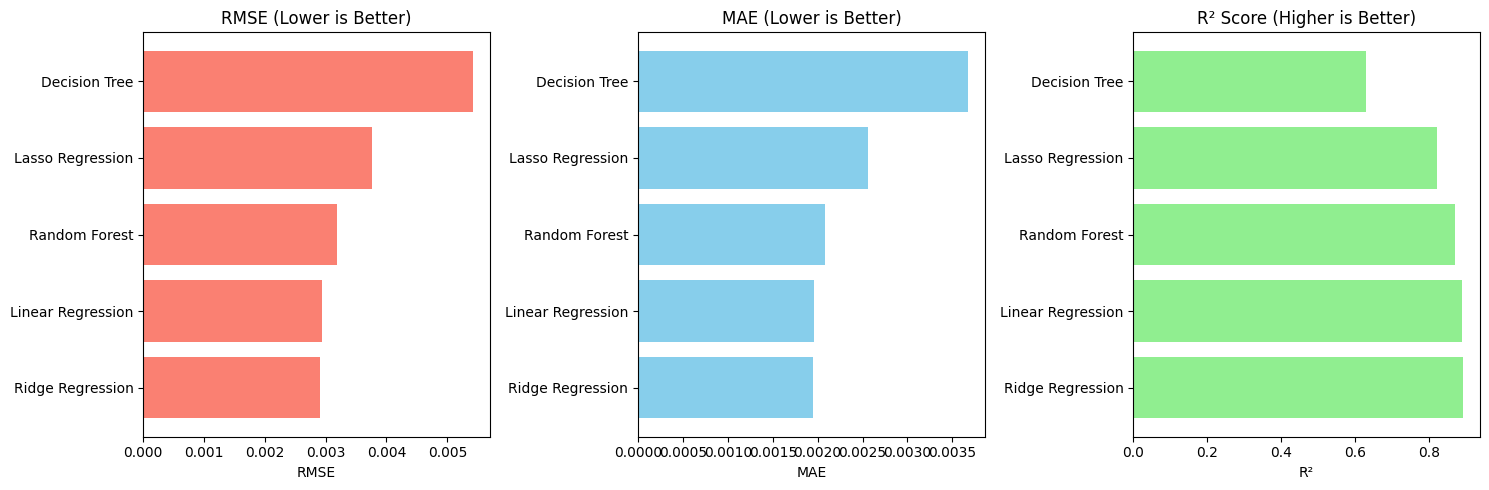

Best Model: Ridge Regression
   R² Score: 0.8934


In [5]:
# Compare all models visually
results_df = pd.DataFrame(results).T.sort_values('R2', ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# RMSE comparison
axes[0].barh(results_df.index, results_df['RMSE'], color='salmon')
axes[0].set_title('RMSE (Lower is Better)')
axes[0].set_xlabel('RMSE')

# MAE comparison
axes[1].barh(results_df.index, results_df['MAE'], color='skyblue')
axes[1].set_title('MAE (Lower is Better)')
axes[1].set_xlabel('MAE')

# R² comparison
axes[2].barh(results_df.index, results_df['R2'], color='lightgreen')
axes[2].set_title('R² Score (Higher is Better)')
axes[2].set_xlabel('R²')

plt.tight_layout()
plt.show()

print("Best Model:", results_df.index[0])
print(f"   R² Score: {results_df['R2'].max():.4f}")

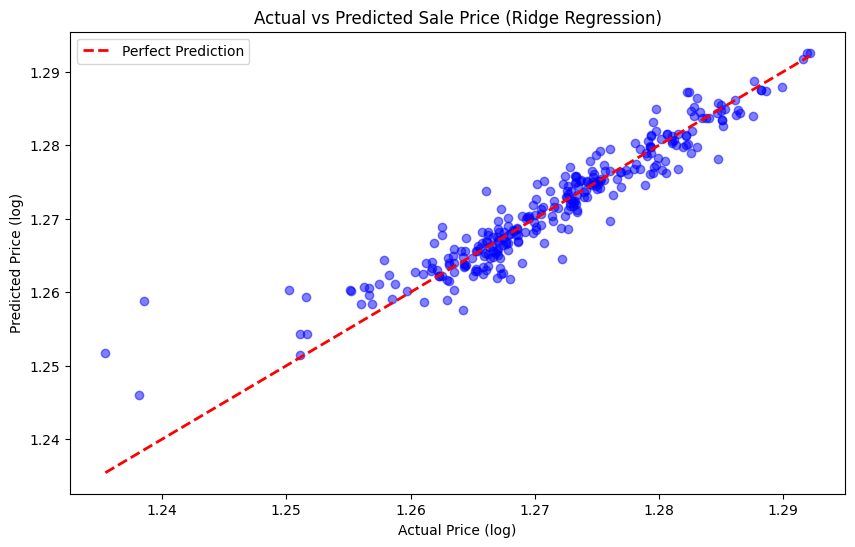

Plot generated!
 Dots close to red line = Good predictions!


In [6]:
# Actual vs Predicted plot for Ridge Regression
ridge = Ridge(alpha=1.0)
ridge.fit(X_train, y_train)
preds = ridge.predict(X_test)

plt.figure(figsize=(10,6))
plt.scatter(y_test, preds, alpha=0.5, color='blue')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 
         'r--', linewidth=2, label='Perfect Prediction')
plt.xlabel('Actual Price (log)')
plt.ylabel('Predicted Price (log)')
plt.title('Actual vs Predicted Sale Price (Ridge Regression)')
plt.legend()
plt.show()

print("Plot generated!")
print(" Dots close to red line = Good predictions!")

In [7]:
import joblib

# Save best model
best_model = Ridge(alpha=1.0)
best_model.fit(X_train, y_train)

joblib.dump(best_model, '../models/best_model.pkl')

print("Best model saved!")
print("models/best_model.pkl")
print(f"\nModel: Ridge Regression")
print(f"R² Score: 0.8934")
print(f"RMSE: 0.0029")



Best model saved!
models/best_model.pkl

Model: Ridge Regression
R² Score: 0.8934
RMSE: 0.0029


In [8]:
import joblib

# Save best model
best_model = Ridge(alpha=1.0)
best_model.fit(X_train, y_train)

joblib.dump(best_model, '../models/best_model.pkl')
print("Best model saved!")

Best model saved!
